In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df=pd.read_csv("fitness.csv")

In [4]:
df.head()

,User_ID,Age,Gender,Fitness_Level,Goal,Workout_Type,Preferred_Duration,Video_ID,Video_Title,Difficulty,Duration,Watch_Time,Rating,Completed
0,U001,22,Female,Beginner,Weight Loss,Cardio,30,V101,Fat Burn Cardio,Beginner,30,28,5,Yes
1,U001,22,Female,Beginner,Weight Loss,Yoga,20,V102,Morning Yoga,Beginner,20,18,4,Yes
2,U002,30,Male,Intermediate,Muscle Gain,Strength,45,V103,Upper Body Strength,Intermediate,45,42,5,Yes
3,U002,30,Male,Intermediate,Muscle Gain,HIIT,25,V104,HIIT Blast,Intermediate,25,20,4,No
4,U003,28,Female,Beginner,Flexibility,Yoga,30,V102,Morning Yoga,Beginner,20,20,5,Yes


In [6]:
df.shape

(20, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   User_ID             20 non-null     object
 1   Age                 20 non-null     int64 
 2   Gender              20 non-null     object
 3   Fitness_Level       20 non-null     object
 4   Goal                20 non-null     object
 5   Workout_Type        20 non-null     object
 6   Preferred_Duration  20 non-null     int64 
 7   Video_ID            20 non-null     object
 8   Video_Title         20 non-null     object
 9   Difficulty          20 non-null     object
 10  Duration            20 non-null     int64 
 11  Watch_Time          20 non-null     int64 
 12  Rating              20 non-null     int64 
 13  Completed           20 non-null     object
dtypes: int64(5), object(9)
memory usage: 2.3+ KB


In [10]:
df.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
Fitness_Level,0
Goal,0
Workout_Type,0
Preferred_Duration,0
Video_ID,0
Video_Title,0
Difficulty,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Age,Preferred_Duration,Duration,Watch_Time,Rating
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,30.500000,29.750000,28.500000,26.250000,4.500000
std,5.771983,9.101041,9.610849,9.054659,0.606977
min,22.000000,15.000000,15.000000,15.000000,3.000000
25%,26.000000,25.000000,20.000000,20.000000,4.000000
50%,29.500000,30.000000,25.000000,24.500000,5.000000
75%,35.000000,30.000000,30.000000,29.250000,5.000000
max,40.000000,50.000000,50.000000,48.000000,5.000000


In [13]:
df['Workout_Type'].value_counts()

,count
Workout_Type,
Yoga,4
Cardio,3
Strength,3
HIIT,3
Dance,2
Pilates,2
Stretching,1
Running,1
Walking,1


In [14]:
df.drop_duplicates(inplace=True)

In [16]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [17]:
df.fillna(df.mode().iloc[0], inplace=True)

Visualization

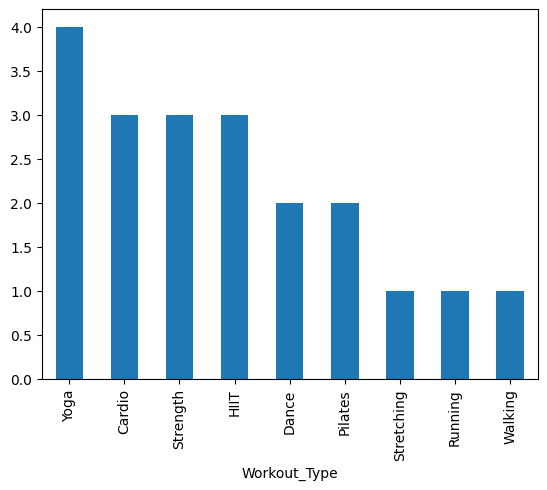

In [18]:
import matplotlib.pyplot as plt

df['Workout_Type'].value_counts().plot(kind='bar')
plt.show()

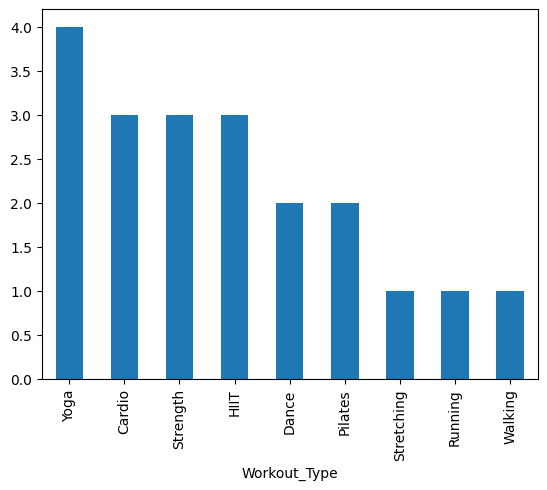

In [19]:
import matplotlib.pyplot as plt

df['Workout_Type'].value_counts().plot(kind='bar')
plt.show()

<Axes: >

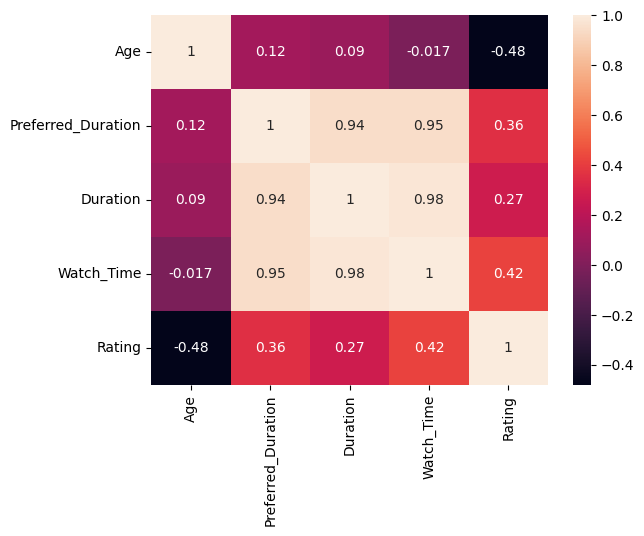

In [20]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)

In [21]:
df['features'] = (
    df['Workout_Type'] + " " +
    df['Difficulty'] + " " +
    df['Goal']
)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

matrix = tfidf.fit_transform(df['features'])

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(matrix)

In [24]:
def recommend(video_index):
    scores = list(enumerate(similarity[video_index]))
    scores = sorted(scores, key=lambda x:x[1], reverse=True)

    for i in scores[1:6]:
        print(df.iloc[i[0]]['Video_Title'])

In [26]:
recommend(10)

Morning Yoga
Morning Yoga
Fat Burn Cardio
Fat Burn Cardio
Fat Burn Cardio


Collaborative Filtering


In [28]:
!pip install surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.0 MB/s eta 0:00:00


In [29]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split

reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    df[['User_ID','Video_ID','Rating']],
    reader
)

trainset, testset = train_test_split(data)

model = SVD()
model.fit(trainset)

In [30]:
model.predict(uid=5, iid=101)

Prediction(uid=5, iid=101, r_ui=None, est=np.float64(4.4375), details={'was_impossible': False})

In [31]:
from surprise.accuracy import rmse

predictions = model.test(testset)
rmse(predictions)

RMSE: 0.4931


np.float64(0.4930766192152)